# AI4I EDA

## Overview

This notebook presents a structured Exploratory Data Analysis (EDA) of the **AI4I** dataset. The goal is to understand the distribution, quality, and predictive value of each feature before any modelling work begins.

The analysis follows a standard EDA pipeline:

1. **SET UP** — libraries, colour palettes, logging, import data, rename columns
2. **TARGET AND OUTCOMES** — Explore target and other outcome variables
3. **MISSING VALUES** — Explore missing values
4. **FEATURE DISTRIBUTIONS** — Explore distributions of ids, cat and num features
5. **CORRELATIONS** — Spearman, Cramer's V and Mutual Information
6. **Outliers** — Find and list outliers
7. **Interactions** — Explore feature interactions identified by correlations
8. **Summary** — Key findings and modelling recommendations are summarised in the final section


================================================================================
## SECTION 1 — SET UP
================================================================================

### 1.1 Data Loading and Canonicalization

The EDA reads exclusively from the Bronze store, pinned to an explicit
dataset version (ds_v1). This binds every figure below to an immutable,
hash-traceable snapshot rather than to whatever happens to sit in a table.
Direct raw-file reads are prohibited by project policy; all access goes
through extract_bronze.


In [79]:
import logging
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

from ml_template.tracking.utils import setup_logging
from ml_template.data.extract import extract_bronze
from ml_template.db.connection import get_engine
logger = logging.getLogger('ml_template.notebooks.eda')
setup_logging()

BI_COLORS = ["#008BFB","#FF0051"]
QUAD_COLORS = ["#008BFB","#FF0051","#00C08A","#E6AC00"]  # SHAP red, SHAP blue, teal, amber

# Primary diverging: matches SHAP's default red↔blue exactly
CMAP_DIV = LinearSegmentedColormap.from_list(
    "shap_div",
    [ "#008BFB", "#ffffff","#FF0051"],
    N=512
)


In [3]:
logger.info('Start EDA')

2026-09-24 09:36:13 | INFO    | ml_template.notebooks.eda | Start EDA


In [4]:
dataset_version_id = "ds_v1"
engine = get_engine()
df = extract_bronze(dataset_version_id, engine=engine)
display(df)

2026-09-24 09:36:16 | INFO    | ml_template.data.extract | Extracted 10000 rows and 16 columns from bronze (version: 'ds_v1', strategy: 'full')


,dataset_version_id,source_row_number,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,ds_v1,1,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,ds_v1,2,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,ds_v1,3,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,ds_v1,4,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,ds_v1,5,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,ds_v1,9996,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,ds_v1,9997,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,ds_v1,9998,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,ds_v1,9999,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   dataset_version_id       10000 non-null  str  
 1   source_row_number        10000 non-null  int64
 2   UDI                      10000 non-null  str  
 3   Product ID               10000 non-null  str  
 4   Type                     10000 non-null  str  
 5   Air temperature [K]      10000 non-null  str  
 6   Process temperature [K]  10000 non-null  str  
 7   Rotational speed [rpm]   10000 non-null  str  
 8   Torque [Nm]              10000 non-null  str  
 9   Tool wear [min]          10000 non-null  str  
 10  Machine failure          10000 non-null  str  
 11  TWF                      10000 non-null  str  
 12  HDF                      10000 non-null  str  
 13  PWF                      10000 non-null  str  
 14  OSF                      10000 non-null  str  
 15  RNF           

The extraction returned the contracted 10,000 rows. All value columns arrive
as strings because Bronze stores CSV content verbatim — type coercion is a
Silver/EDA responsibility, by design. dataset_version_id and
source_row_number are lineage columns, not features.

At this point we can cast data types for int, float and str and rename to features to canonical names

In [6]:
canonical_names = {
    "UDI": "udi",
    "Product ID": "product_id",
    "Type": "type",
    "Air temperature [K]": "air_temperature_k",
    "Process temperature [K]": "process_temperature_k",
    "Rotational speed [rpm]": "rotational_speed_rpm",
    "Torque [Nm]": "torque_nm",
    "Tool wear [min]": "tool_wear_min",
    "Machine failure": "machine_failure",
    "TWF": "twf",
    "HDF": "hdf",
    "PWF": "pwf",
    "OSF": "osf",
    "RNF": "rnf",
}

canonical_dtypes = {
    "udi": "int64",
    "product_id": "string",
    "type": "category",
    "air_temperature_k": "float64",
    "process_temperature_k": "float64",
    "rotational_speed_rpm": "int64",
    "torque_nm": "float64",
    "tool_wear_min": "int64",
    "machine_failure": "int8",
    "twf": "int8",
    "hdf": "int8",
    "pwf": "int8",
    "osf": "int8",
    "rnf": "int8",
}

df = df.rename(columns=canonical_names).astype(canonical_dtypes)

Columns are renamed to canonical snake_case identifiers and cast to the
dtypes declared in the dataset contract. udi and product_id remain for
traceability. No cast failures occurred: a .astype() error here would have
indicated corrupt source content worth investigating upstream.

================================================================================
## SECTION 2 — TARGET AND OUTCOMES
================================================================================

machine_failure is the modelling target; twf, hdf, pwf, osf, rnf
are outcome columns — derived failure-mode labels that must never enter the
feature set. Before any analysis we verify the label vocabulary is binary
and quantify label consistency between modes and target.

In [7]:
import yaml
from pathlib import Path

# Load configurations
parent_path = Path("..").resolve()
print(parent_path)
conf_path = Path(parent_path / "configs/ai4i_binary.yaml")
with conf_path.open("r", encoding="utf-8") as file:
    data_config = yaml.safe_load(file)

# Get original feature names
target = data_config['bronze_source_contract']['roles']['target']
outcome = data_config['bronze_source_contract']['roles']['outcome']

# convert to canonical names
target = [canonical_names.get(col, col) for col in target]
outcome = [canonical_names.get(col, col) for col in outcome]

# Useful combo
all_targets = target + outcome
print(all_targets)  
print(target)

/home/python_user/coding/ds/tabular-ml-template
['machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf']
['machine_failure']


This dataset has an unusual target, outcome structure. According to download source twf, hdf, pwf, osf and rnf are failure modes. If one of the is one, machine failure is one. machine failure is the main target. We check the dataset consistency between the outcomes and target.

In [8]:
tot_positives = 0
for name in all_targets:
    number_of_positives = df[name].sum()
    print(f'{name} values: {df[name].unique().tolist()}. Total number of positive: {number_of_positives}')
    tot_positives += number_of_positives if name != 'machine_failure' else 0 
    
print(f'Total number of failure mode positives: {tot_positives}')


sum_f_modes = df[outcome].sum(axis=1)
number_of_multiple_f_modes = sum_f_modes[sum_f_modes > 1].count()
sum_of_multiple_f_modes = sum_f_modes[sum_f_modes > 1].sum()
additional_f_modes = sum_of_multiple_f_modes - number_of_multiple_f_modes

print(f'Number of multiple failure modes: {number_of_multiple_f_modes}')
print(f'Double check: {tot_positives - number_of_multiple_f_modes}')
print(additional_f_modes, sum_of_multiple_f_modes, number_of_multiple_f_modes)

f_mode_pos_mf_neg = df[(df[outcome].sum(axis=1) > 0) & (df['machine_failure'] == 0)]['machine_failure'].count()
print(f'Number of times failure mode is positive and machine failure is negative: {f_mode_pos_mf_neg}')

f_mode_neg_mf_pos = df[(df[outcome].sum(axis=1) == 0) & (df['machine_failure'] == 1)]['machine_failure'].count()
print(f'Number of time failure mode is negative and machine failure is positive: {f_mode_neg_mf_pos}')


machine_failure values: [0, 1]. Total number of positive: 339
twf values: [0, 1]. Total number of positive: 46
hdf values: [0, 1]. Total number of positive: 115
pwf values: [0, 1]. Total number of positive: 95
osf values: [0, 1]. Total number of positive: 98
rnf values: [0, 1]. Total number of positive: 19
Total number of failure mode positives: 373
Number of multiple failure modes: 24
Double check: 349
25 49 24
Number of times failure mode is positive and machine failure is negative: 18
Number of time failure mode is negative and machine failure is positive: 9


All six columns are strictly binary. There are 373 failure-mode positives
against 339 target positives. 24 rows carry multiple failure modes. Two
label-consistency violations exist: 18 rows where a failure mode is active
but machine_failure = 0, and 9 rows where machine_failure = 1 has no
active mode. This noise (0.27% of rows) is documented as external label
behaviour, not a pipeline bug — the target is used as-is.

Check distribution and imbalance of target and outcomes.

In [10]:
# Summarize outcome and target distributions
outcome_vc_list = []
column_names = []
for name in all_targets:
    vc = df[name].value_counts()
    outcome_vc_list.append(vc)
    column_names.append(name)
    
df_outcome_vc = pd.concat(outcome_vc_list, axis=1, keys=column_names).T
df_outcome_vc['proportion_%'] = round(df_outcome_vc[1] / len(df) * 100, 2)
df_outcome_vc['ratio'] = round(df_outcome_vc[0] / df_outcome_vc[1], 2)
display(df_outcome_vc)



,0,1,proportion_%,ratio
machine_failure,9661,339,3.39,28.50
twf,9954,46,0.46,216.39
hdf,9885,115,1.15,85.96
pwf,9905,95,0.95,104.26
osf,9902,98,0.98,101.04
rnf,9981,19,0.19,525.32


The target has 339 positive cases (3.39%, ratio 28.5:1) — class imbalance
is severe enough that accuracy is meaningless and stratified splitting is
required. The rarest mode (rnf, 19 cases) is the least reliable label of
the six and also the least correlated with the target (Cramér's V = 0.16 for
twf shows modes add no independent signal to the label).

================================================================================
## SECTION 3 — MISSING VALUES
================================================================================

Three null classes are distinguished: (1) structural nulls — impossible,
since non-numeric tokens would have surfaced during casting above;
(2) target/outcome nulls — impossible, vocabularies are binary;
(3) proxy nulls — sentinel numerics and boundary spikes, checked below.

In [11]:
missing = df.isnull().sum()
print(missing)

dataset_version_id       0
source_row_number        0
udi                      0
product_id               0
type                     0
air_temperature_k        0
process_temperature_k    0
rotational_speed_rpm     0
torque_nm                0
tool_wear_min            0
machine_failure          0
twf                      0
hdf                      0
pwf                      0
osf                      0
rnf                      0
dtype: int64


Zero structural nulls across all columns. The dataset is synthetic and
clean; no imputation strategy is required. The Silver layer retains a
nullability check as a guard for future versions, but it is a gate, not a
transform.

Since all the feature were str before casting any non int/float would have been cast to nan. For the outcomes we know they are all [0,1], so no null. Remaining are common imputation values for numbers. Check for negative numbers and proxy nulls 99, 999, 9999. Also later check for spikes in the distributions

In [20]:
ids = data_config['bronze_source_contract']['roles']['id']
feature = data_config['bronze_source_contract']['roles']['feature']

# convert to canonical names
ids = [canonical_names.get(col, col) for col in ids]
feature = [canonical_names.get(col, col) for col in feature]
print(f"Id columns : {ids}")
print(f"All feature columns: {feature}")

# cat, num features
cat_feature = ['type']
num_feature = [name for name in feature if name not in cat_feature]
print(f"Categorical features: {cat_feature}")
print(f'Numeric features: {num_feature}')

Id columns : ['udi', 'product_id']
All feature columns: ['type', 'air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
Categorical features: ['type']
Numeric features: ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']


In [34]:
df_stats = df[num_feature].describe().loc[['min', 'max'], :]
display(df_stats)

# Number of unexpected negative numbers
number_of_negative = 0
for cname in num_feature:    
    number_of_negative += len(df[df[cname] < 0])

print(f'Number of unexpected negative values: {number_of_negative}')

# Number of unexpected zeros (excluding totla_wear_min which includes 0)
non_zero_features = [name for name in feature if name != 'tool_wear_min']
number_of_zeros = 0
for cname in non_zero_features:
    number_of_zeros += len(df[df[cname] == 0])
print(f'Number of unexpected zeros: {number_of_zeros}')

# For other non-zero proxies we need a dict of which features values do not cover the proxies
null_proxy_list = [99, 999, 9999]
proxy_check_dict = {}
for v in null_proxy_list:
    check_cols = df_stats.columns[df_stats.loc['max'] < v].tolist()
    proxy_check_dict[str(v)] = check_cols

dict_number_of_proxy_nulls = {}
for k,v in proxy_check_dict.items():
    number_of_sus = 0
    for cname in v:
        number_of_sus += len(df[df[cname] == int(k)])
    dict_number_of_proxy_nulls[k] = number_of_sus
    
print(dict_number_of_proxy_nulls)

,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min
min,295.3,305.7,1168.0,3.8,0.0
max,304.5,313.8,2886.0,76.6,253.0


Number of unexpected negative values: 0
Number of unexpected zeros: 0
{'99': 0, '999': 0, '9999': 0}


Categorical features with low number of categories can be checked with .unique(), so left to check are proxy null for numerical featues. We check for negative numbers, zeros, 99, 999 and 9999 in columns we wouldn't expect them. There conclusion is that there are no nans in this dataset

================================================================================
## SECTION 4 — FEATURE DISTRIBUTIONS
================================================================================

### 4.1. Id Cols

This dataset has two id columns `udi` and `product id`. We want to check if they carry any information.

In [35]:
for name in ids:
    print(f"{name} number of unique values: {df[name].nunique()}")
    

udi number of unique values: 10000
product_id number of unique values: 10000


Both identifier columns are fully unique (10,000 values). They carry no
predictive content and are excluded from the feature set; product_id
embeds the L/M/H series prefix which is already represented in type.

### 4.2. Study Features

Start by checking if each feature is numerical or categorical

In [36]:
for name in feature:
    print(f"{name} number of unique values: {df[name].nunique()}")


type number of unique values: 3
air_temperature_k number of unique values: 93
process_temperature_k number of unique values: 82
rotational_speed_rpm number of unique values: 941
torque_nm number of unique values: 577
tool_wear_min number of unique values: 246


Based on the number of unique values we will study `type` as categorical and all other as numerical

### 4.3 Categorical analysis

Checking the distribution of categorical feature `type`.

type
L    6000
M    2997
H    1003
Name: count, dtype: int64

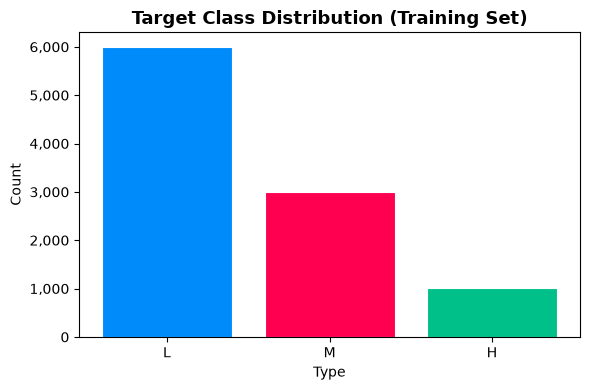

In [69]:
vc = df['type'].value_counts()
display(vc)

# Plot class counts
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    vc.index, vc.values, color=QUAD_COLORS, edgecolor="white", linewidth=0.8
)

ax.set_title("Target Class Distribution (Training Set)", fontsize=13, fontweight="bold")
ax.set_xlabel("Type")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

The product mix is imbalanced: L 60%, M 30%, H 10%. The high-quality series
is under-represented, which matters because type is one of the strongest
target-associated features: joint statistics condition on a minority class.

machine_failure,0,1
type,,
L,5765,235
M,2914,83
H,982,21


<Axes: xlabel='type', ylabel='count'>

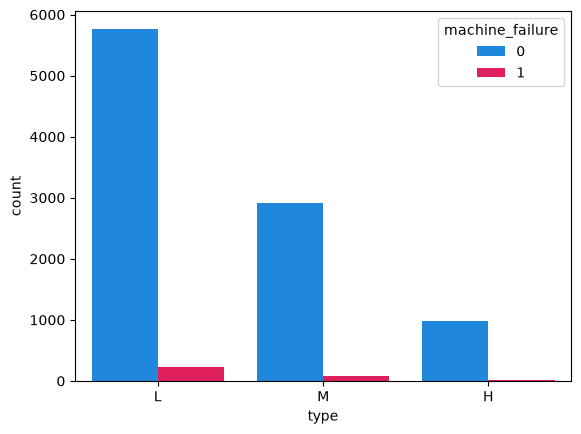

In [78]:
# Contingency table: type vs machine_failure
ct = pd.crosstab(df["type"], df["machine_failure"]).reindex(["L", "M", "H"])
display(ct)

# Grouped bar setup
labels = ct.index.tolist()
x = np.arange(len(labels))
width = 0.35


category_order = df['type'].value_counts().sort_values(ascending=False).index.tolist()

sns.countplot(
    data=df, 
    x='type', 
    hue='machine_failure', 
    order=category_order,  # <-- Sorts the X-axis
    palette=BI_COLORS
)

### 4.4. Numerical Features

In [39]:

print(num_feature)
print(cat_feature)

['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min']
['type']


In [44]:
df_stats = df[num_feature].describe()
df_stats.loc['skew'] = df[num_feature].skew()
df_stats.loc['kurt'] = df[num_feature].kurtosis()
print(df_stats)

       air_temperature_k  process_temperature_k  rotational_speed_rpm  \
count       10000.000000           10000.000000          10000.000000   
mean          300.004930             310.005560           1538.776100   
std             2.000259               1.483734            179.284096   
min           295.300000             305.700000           1168.000000   
25%           298.300000             308.800000           1423.000000   
50%           300.100000             310.100000           1503.000000   
75%           301.500000             311.100000           1612.000000   
max           304.500000             313.800000           2886.000000   
skew            0.114274               0.015027              1.993171   
kurt           -0.835962              -0.499734              7.392945   

          torque_nm  tool_wear_min  
count  10000.000000   10000.000000  
mean      39.986910     107.951000  
std        9.968934      63.654147  
min        3.800000       0.000000  
25%       3

In [45]:
df_stats.loc['coef_var'] = df_stats.loc['std',:] / df_stats.loc['mean',:]

num_feature_unique_values = {}
for name in num_feature:
    num_feature_unique_values[name] = df[name].nunique()
df_stats.loc['unique_values'] = num_feature_unique_values

display(df_stats.loc[['coef_var', 'unique_values']].T)

,coef_var,unique_values
air_temperature_k,0.006667,93.0
process_temperature_k,0.004786,82.0
rotational_speed_rpm,0.116511,941.0
torque_nm,0.249305,577.0
tool_wear_min,0.589658,246.0


Temperatures are nearly constant in range (CV < 1%) but retain useful
resolution (80–93 distinct values). rotational_speed_rpm is right-skewed
(skew ≈ 2.0, excess kurtosis ≈ 7.4) — a heavy upper tail rather than bulk
variation. torque_nm is symmetric. tool_wear_min is uniform on
[0, 253] — a rectangular run-to-reset counter, not a physical distribution.

Plot the numeric features distributions

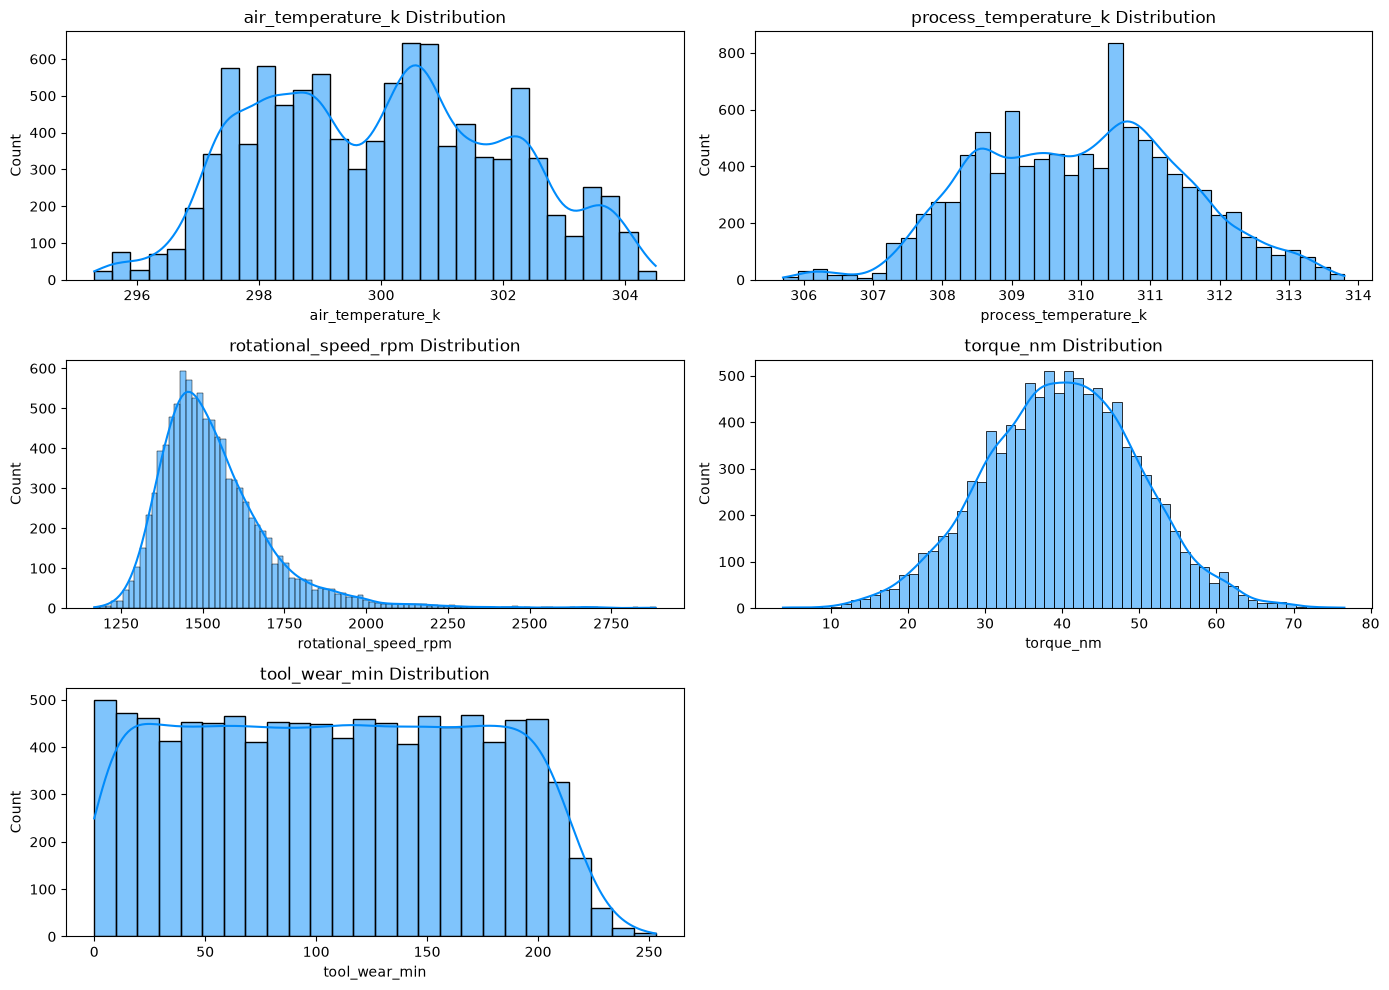

In [ ]:

def hist_plot(df, cols):
    plt.figure(figsize=(14, len(cols) * 2))

    for i, col in enumerate(cols):
        # Fix: Use 2 for both the row math and the column count
        plt.subplot((len(cols) + 1) // 2, 2, i + 1)
        # Use histplot for distributions
        sns.histplot(data=df, x=col, kde=True, color=BI_COLORS[0]) 
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()

hist_plot(df, num_feature)

Shape-wise there are a couple of different distributions here, `rotational_speed_rpm` and `torque-nm` are reasonable normal, if a bit skewed. `tool_wear_min` is rectangular. `air_temperature_k` asnd `process_temperature_k` are multimodal and maybe normal.

Let's look at distribution by target.

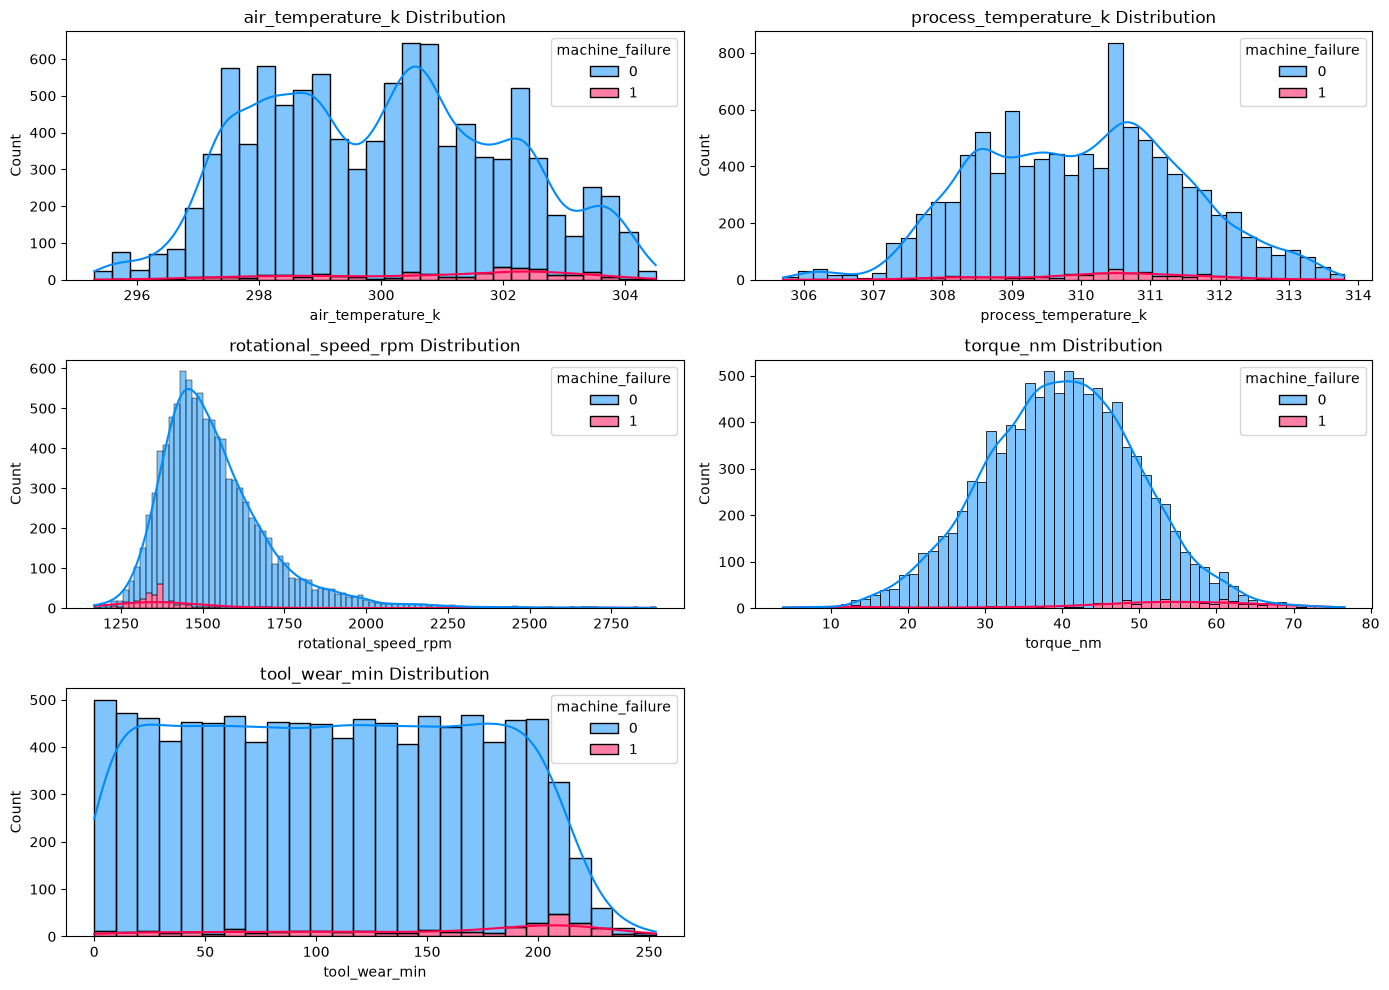

In [ ]:

def distribution_by_target(df, cols):
    plt.figure(figsize=(14, len(cols) * 2))

    for i, col in enumerate(cols):
        # Fix: Use 2 for both the row math and the column count
        plt.subplot((len(cols) + 1) // 2, 2, i + 1)
        # Use histplot for distributions
        sns.histplot(data=df, hue=target[0], multiple="stack", 
                    x=col, kde=True, palette=BI_COLORS)
        plt.title(f"{col} Distribution")

    plt.tight_layout()
    plt.show()
    
distribution_by_target(df, num_feature)

Since the number of positive cases is so low it is a bit hard to discerne anything. However, `rotational_speed_rpm`, `torque_nm` and `tool_wear_min` seem to have reasonably different distributions.

Let's look at joint distributions

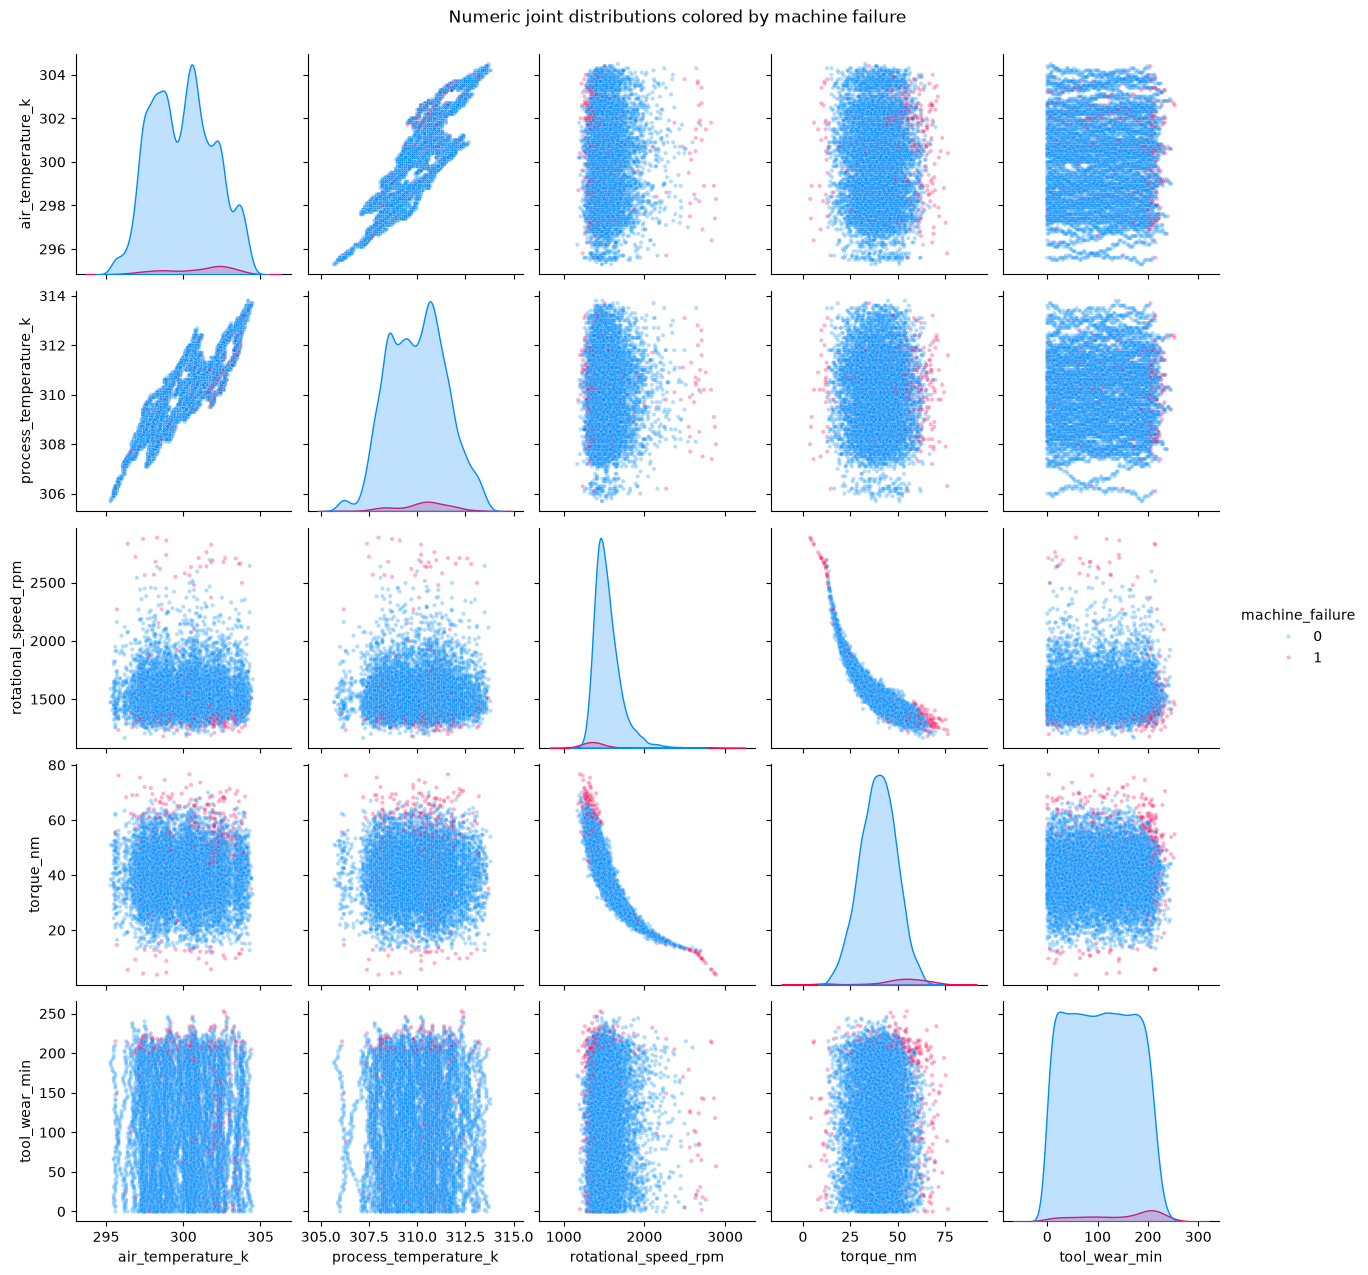

In [56]:
# df is small enough can plot all, no need to sample.

sns.pairplot(
    df[num_feature + target],
    hue=target[0],      # color by machine failure
    palette=BI_COLORS,
    diag_kind="kde",
    plot_kws={"alpha": 0.3, "s": 9}
)
plt.suptitle("Numeric joint distributions colored by machine failure", y=1.02)
plt.show()

The class boundary is structured and partially separable: positives occupy
characteristic corners of (RPM, torque, wear) space. Axis-aligned splits
should capture this efficiently — favourable for tree models.

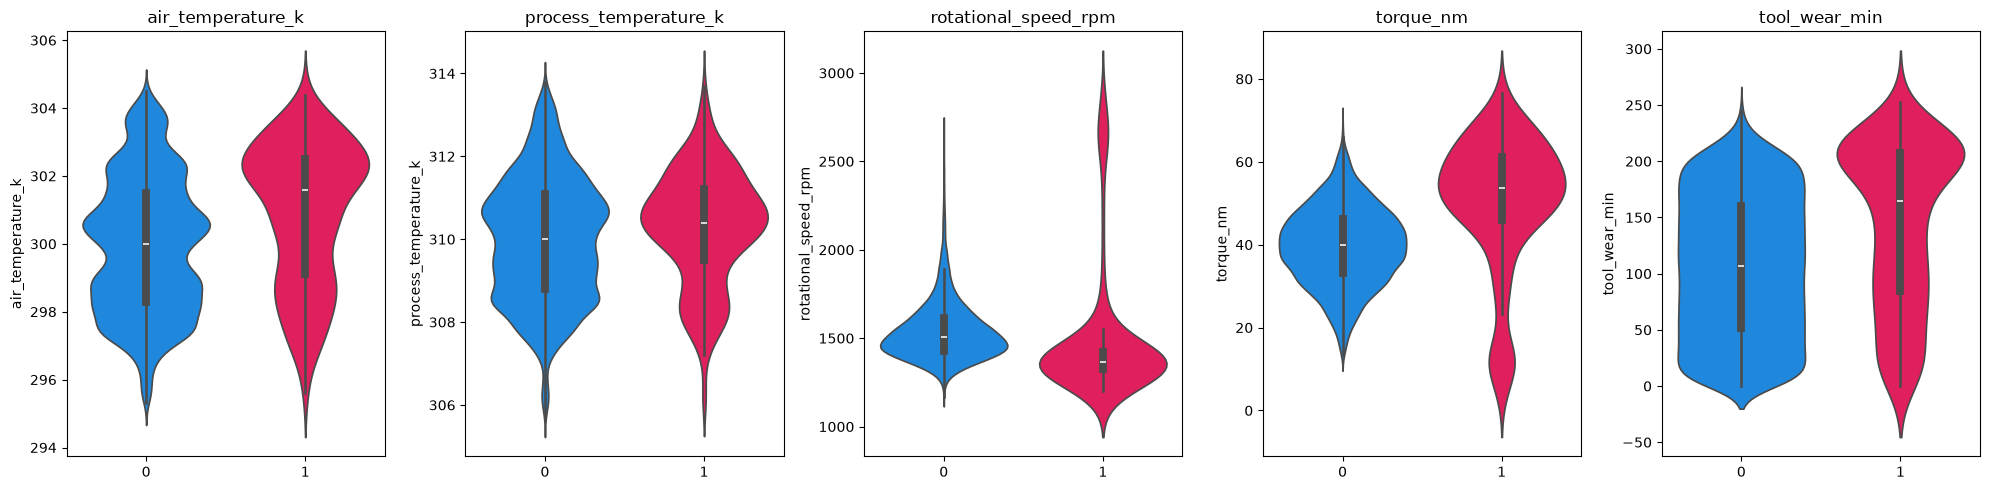

In [82]:
# 2. Initialize the 1x6 grid of subplots
# sharey=False is critical so each plot scales to its own data range
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

# 3. Loop through your features and plot them onto the subplots
for i, col in enumerate(num_feature):
    sns.violinplot(
        data=df,
        x='machine_failure',     # Puts target categories on the X-axis
        y=col,            # Puts the specific feature on the Y-axis
        hue='machine_failure',   # Splits/colors by target
        ax=axes[i],       # Places the plot into the specific subplot column
        legend=False,     # Hides individual legends to keep it clean
        palette=BI_COLORS
    )
    
    # Optional: Clean up titles and labels
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('')  # Removes redundant target column text on X-axis

# Adjust layout so labels don't overlap
plt.tight_layout()
plt.show()

================================================================================
## SECTION 5 — CORRELATIONS
================================================================================

### 5.1 Spearman Correlation for Numerical Features

Visualize monotonic feature correlation

In [57]:

def plot_heatmap(df, title="Heatmap"):
    # 1. Compute the correlation matrix
    corr = df.corr(numeric_only=True)
    
    # 2. Create a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # 3. Set up the figure
    plt.figure(figsize=(10, 8))
    
    # 4. Draw the heatmap
    sns.heatmap(corr, 
                #mask=mask, 
                annot=True,          # Show the correlation numbers
                fmt=".2f",           # Limit to 2 decimal places
                cmap=CMAP_DIV,     # Red for positive, blue for negative
                center=0,            # Ensure 0 is the neutral color
                square=True,         # Make cells square
                linewidths=.5)       # Add thin lines between cells
    
    plt.title(title, fontsize=15)
    plt.show()

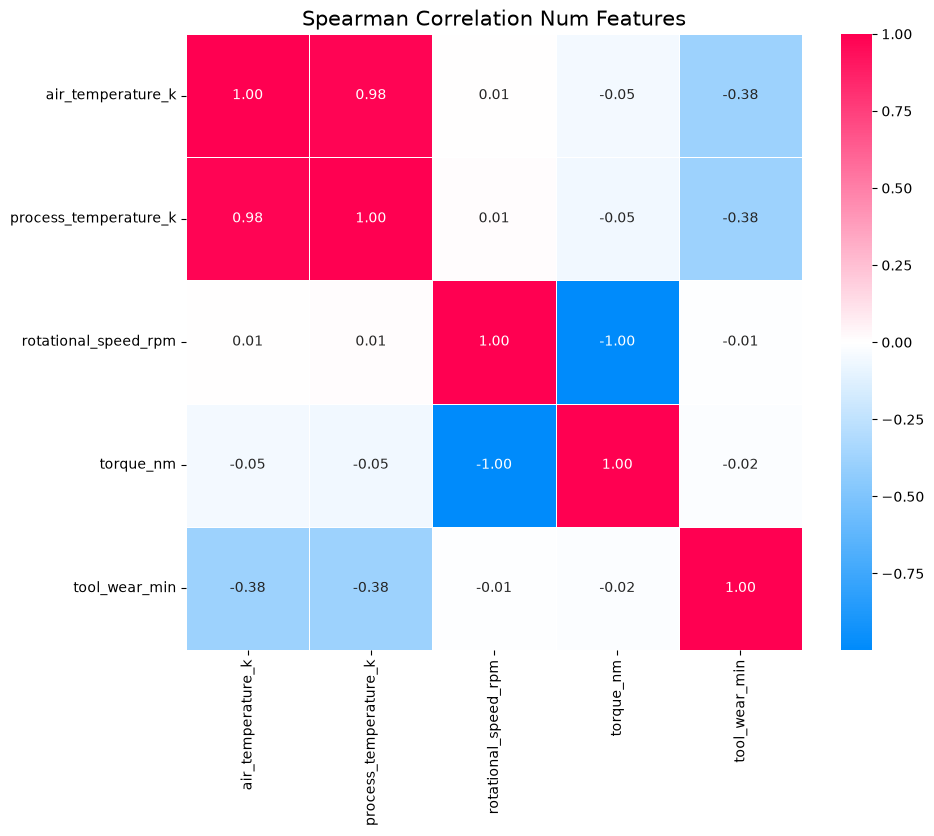

In [60]:
spearman_corr = df[num_feature].corr('spearman')
plot_heatmap(spearman_corr, title='Spearman Correlation Num Features')

Two near-redundant pairs exist: air/process temperature and RPM/torque
(the latter being strongly negatively coupled — mechanical load
characteristic). Effective independent numeric signal ≈ 3 features, not 5.
Tree models keep all five without penalty; a linear basline must drop one
of each pair or accept inflated coefficients.

### 5.2 Cramer's V for Categorical Columns

Visualize Cramer's V for all the categorical columns

In [61]:
from scipy.stats import chi2_contingency
from itertools import combinations

# ======================================================
# 1) Cramer's V matrix for categorical–categorical
# ======================================================
def cramers_v_matrix(df: pd.DataFrame, cat_cols: list[str] | None=None) -> pd.DataFrame:
    """
    Compute a symmetric Cramer's V association matrix between categorical columns.
    Returns a DataFrame suitable for a heatmap.
    """
    # Internal Cramer's V with bias correction
    def cramers_v(x, y):
        confusion = pd.crosstab(x, y)
        if confusion.size == 0:
            return np.nan
        chi2, _, _, _ = chi2_contingency(confusion, correction=False)
        n = confusion.to_numpy().sum()
        r, k = confusion.shape
        phi2 = chi2 / n
        phi2corr = max(0, phi2 - (k - 1) * (r - 1) / (n - 1))
        rcorr = r - (r - 1) ** 2 / (n - 1)
        kcorr = k - (k - 1) ** 2 / (n - 1)
        denom = min((kcorr - 1), (rcorr - 1))
        if denom <= 0:
            return np.nan
        return np.sqrt(phi2corr / denom)

    n = len(cat_cols)
    v_matrix = pd.DataFrame(
        np.eye(n, dtype=float),
        index=cat_cols,
        columns=cat_cols
    )

    for i, j in combinations(range(n), 2):
        col_i, col_j = cat_cols[i], cat_cols[j]
        v = cramers_v(df[col_i], df[col_j])
        v_matrix.iloc[i, j] = v
        v_matrix.iloc[j, i] = v

    return v_matrix


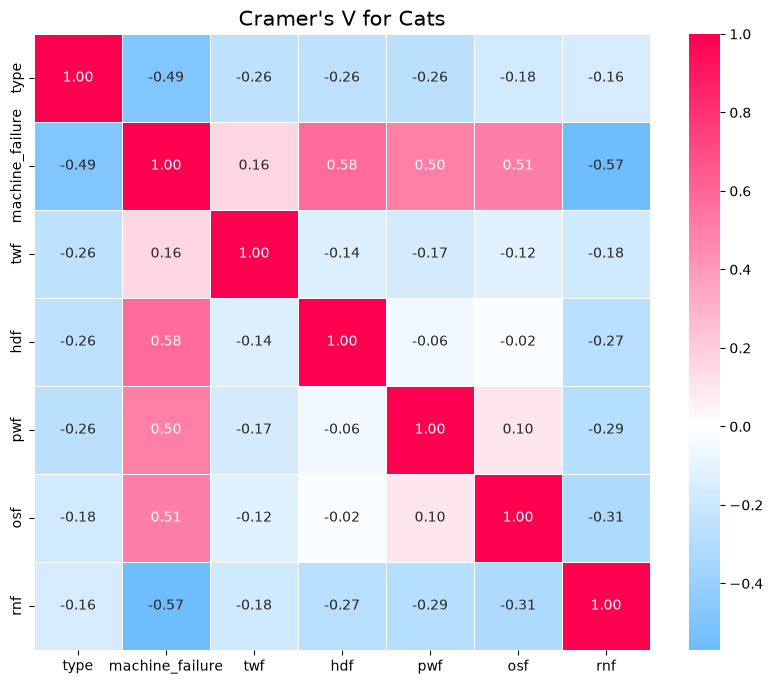

In [62]:
c_matrix = cramers_v_matrix(df, cat_feature+all_targets)
plot_heatmap(c_matrix, title="Cramer's V for Cats")

type relates meaningfully to the target — quality series is a real risk
factor, not capture error. The five outcome columns are strongly associated
with each other and the target by construction; their role in this panel is
documentation only (they are leakage if used as features).

### 5.3. Mutual Information for Features, Targets and Outcomes

We can use Mutual Information to calculate non-linear association between all features and outcomes.

In [63]:
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from sklearn.preprocessing import LabelEncoder

# Calulcate MI matrix for numerical and categorical columns
def calculate_mi_matrix(df, num_cols, cat_cols):
    all_cols = num_cols + cat_cols
    n = len(all_cols)
    mi_matrix = np.zeros((n, n))
    
    # 1. Encode only categorical features
    df_encoded = df[all_cols].copy()
    label_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le

    # 2. Identify discrete features by index for the MI functions
    # (True if the column is in cat_cols)
    is_discrete = [col in cat_cols for col in all_cols]

    # 3. Calculate Pairwise MI
    for i in range(n):
        for j in range(i, n):
            X = df_encoded.iloc[:, [i]]
            y = df_encoded.iloc[:, j]
            
            # Determine estimator based on target variable type (y)
            if is_discrete[j]:
                mi = mutual_info_classif(X, y, discrete_features=[is_discrete[i]])
            else:
                mi = mutual_info_regression(X, y, discrete_features=[is_discrete[i]])
            
            mi_matrix[i, j] = mi[0] if isinstance(mi, np.ndarray) else mi
            mi_matrix[j, i] = mi_matrix[i, j]
            
    return pd.DataFrame(mi_matrix, index=all_cols, columns=all_cols)

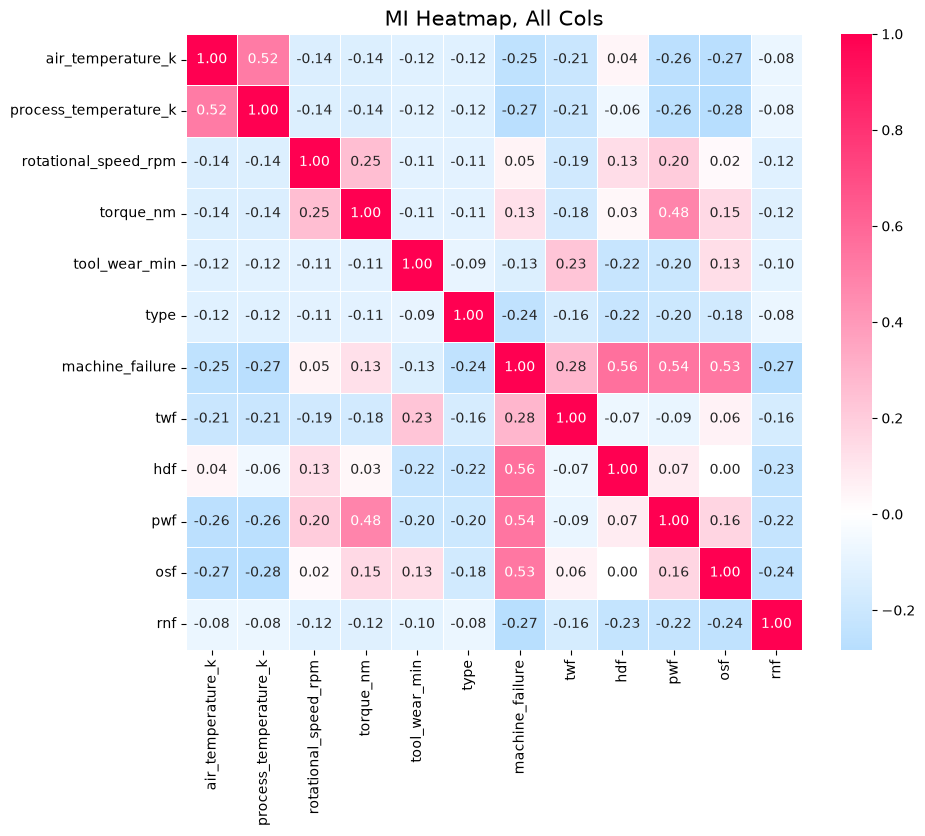

In [64]:
mi_matrix = calculate_mi_matrix(df, num_feature, cat_feature+all_targets)
plot_heatmap(mi_matrix, title='MI Heatmap, All Cols')

From the heatmaps we can draw some conclusions about the features. `air_temperature_k` and `process_temperature_k` are highly Spearman correlated as are `rotational_speed_rpm` and `torque_nm`. We can focus on one of each. From The MI Heatmap we can conclude that `process_temprature_k`, `torque_nm`, `tool_wear_min` and `type` show some predictive power for `machine_failure`  

================================================================================
## SECTION 6 — OUTLIERS
================================================================================

### 6.1 Numeric Outliers

IQR fences are used as diagnostics, not deletion criteria. The intent is to
check whether far values are isolated errors or structured failure regimes.

In [65]:
outlier_info = {}

for col in num_feature:
    s = df[col].astype(float)
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr

    mask = (s < lo) | (s > hi)
    outlier_info[col] = {
        "low_thresh": round(lo,2),
        "high_thresh": round(hi,2),
        "n_outliers": int(mask.sum()),
        "pct_outliers": round(float(mask.mean() * 100),3)
    }

outlier_info

{'air_temperature_k': {'low_thresh': 293.5,
  'high_thresh': 306.3,
  'n_outliers': 0,
  'pct_outliers': 0.0},
 'process_temperature_k': {'low_thresh': 305.35,
  'high_thresh': 314.55,
  'n_outliers': 0,
  'pct_outliers': 0.0},
 'rotational_speed_rpm': {'low_thresh': 1139.5,
  'high_thresh': 1895.5,
  'n_outliers': 418,
  'pct_outliers': 4.18},
 'torque_nm': {'low_thresh': 12.8,
  'high_thresh': 67.2,
  'n_outliers': 69,
  'pct_outliers': 0.69},
 'tool_wear_min': {'low_thresh': -110.5,
  'high_thresh': 325.5,
  'n_outliers': 0,
  'pct_outliers': 0.0}}

418 RPM readings (4.2%) pass the upper fence and 69 torque values pass too.
In context these are not errors — the top Isolation-Forest rows are all
high-wear, extreme RPM/torque combinations, which is precisely the
failure-prone regime. No rows are removed; outlier handling is limited
to informing model choice (trees over distance-based models).

### 6.2 Isolation Forest Outlier Detection

In [66]:
# Drop target from features
X = df[feature]


# 3. Preprocess: scale numerics, one-hot categoricals
numeric_tf = StandardScaler()
categorical_tf = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_tf, num_feature),
        ("cat", categorical_tf, cat_feature),
    ]
)

# 4. Isolation Forest
iso = IsolationForest(
    n_estimators=200,
    max_samples=256,
    contamination=0.01,    # expected fraction of anomalies (tune)
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline([("pre", pre),("iso", iso),])

pipe.fit(X)

# 5. Get anomaly scores and flags
# decision_function: higher = more normal, lower = more anomalous
scores = pipe["iso"].decision_function(pipe["pre"].transform(X))
labels = pipe["iso"].predict(pipe["pre"].transform(X))  # 1 = normal, -1 = anomaly

X["iso_score"] = scores
X["iso_label"] = labels        # -1 = flagged outlier

# Inspect most anomalous rows
n_anomaly = len(X[X.iso_label == -1])
print(f'Number of outlier: {n_anomaly}')
outliers = X.sort_values("iso_score").head(20)
display(outliers[["iso_score", 'iso_label'] + num_feature + cat_feature])

Number of outlier: 100


,iso_score,iso_label,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,type
5152,-0.070158,-1,304.3,313.5,2643,12.7,21,L
887,-0.064570,-1,295.7,306.2,2161,16.5,105,H
1209,-0.058085,-1,297.0,308.1,2540,13.3,98,H
5647,-0.057867,-1,302.5,311.8,2370,14.7,198,H
8114,-0.056778,-1,300.4,311.8,2496,13.5,5,H
847,-0.055187,-1,296.4,307.4,2833,5.6,213,L
4988,-0.052963,-1,303.8,313.1,2497,13.0,5,L
901,-0.050636,-1,295.6,306.1,1256,62.3,142,H
9939,-0.050492,-1,298.3,308.1,2636,12.8,84,H
4997,-0.050358,-1,303.6,312.8,2659,11.4,26,M


The 1% flag budget (100 rows, contamination=0.01) lands almost entirely in
the known stress corner of feature space, and no cluster of "clean" rows is
flagged. The flagged set overlaps heavily with observed failures.

### 6.3 PCA

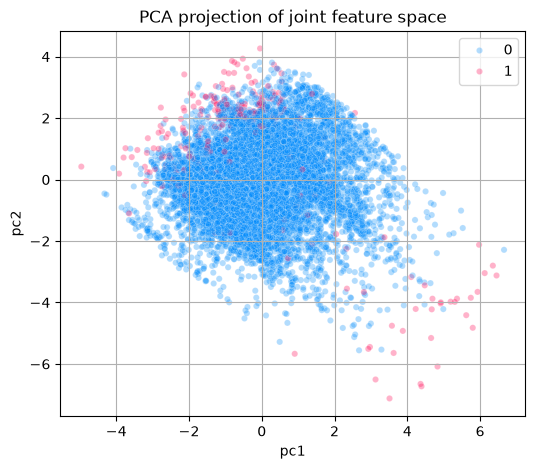

In [67]:
#
X_PCA = df[feature]
y_PCA = df[target[0]]

pre = ColumnTransformer([
    ("num", StandardScaler(), num_feature),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feature),
])

X_enc = pre.fit_transform(X_PCA)   # sparse matrix is fine

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_enc)  # for large data, sample first

pca_df = pd.DataFrame({
    "pc1": X_pca[:, 0],
    "pc2": X_pca[:, 1],
    target[0]: y_PCA,
})

plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=pca_df,  # sample for speed/clarity
    x="pc1", y="pc2", hue=target[0], palette=BI_COLORS, alpha=0.3, s=20
)
plt.title("PCA projection of joint feature space")
plt.legend()
plt.grid(True)
plt.show()

PCA collapses the data into one bulk cloud — low global separability — but
the positive class accumulates at its edges. Combined with the pairplot,
this says: the signal is local and conditional, not global and linear.

================================================================================
## SECTION 7 — INTERACTIONS
================================================================================

Pairs are chosen from the MI/Cramér leaders, not all 15: the informative
set is (process_temperature_k, torque_nm, tool_wear_min, type).
Equal-count quantile bins are used so each cell has comparable support; a
mean-failure-rate heatmap and a row-count heatmap are read together.

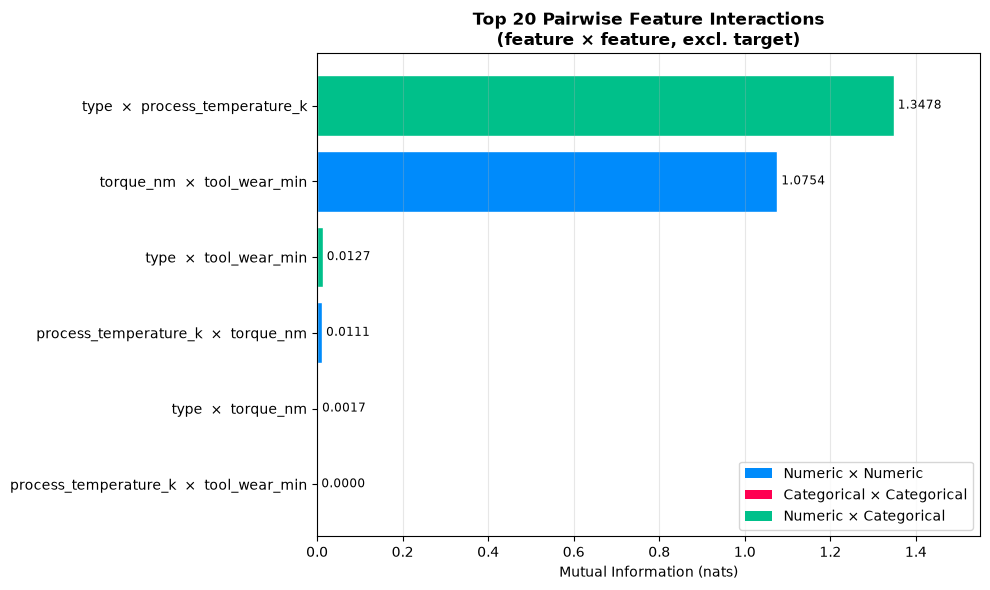

In [83]:
# ══════════════════════════════════════════════════════════════════════════════
# TOP X PAIRWISE FEATURE INTERACTIONS  (feature × feature, no target)
# ══════════════════════════════════════════════════════════════════════════════
ALL_FEATS = ['type', 'process_temperature_k', 'torque_nm', 'tool_wear_min']
NUMBER_OF_FEATURES = 20

# ── Extract upper triangle pairs ──────────────────────────────────────────────
rows, cols_idx = np.triu_indices(len(ALL_FEATS), k=1)

pair_mi = (
    pd.Series(
        {f"{ALL_FEATS[i]}  ×  {ALL_FEATS[j]}": mi_matrix.iloc[i, j]
         for i, j in zip(rows, cols_idx)}
    )
    .sort_values(ascending=False)
    .head(NUMBER_OF_FEATURES)
    .sort_values(ascending=True)   # flip for horizontal bar readability
)

# ── Color each bar by interaction type ───────────────────────────────────────
# num×num → blue | cat×cat → red | num×cat → teal
def pair_color(label):
    f1, f2 = [f.strip() for f in label.split("×")]
    f1_cat = f1 in cat_feature
    f2_cat = f2 in cat_feature
    if not f1_cat and not f2_cat:
        return QUAD_COLORS[0]          # blue  — num × num
    elif f1_cat and f2_cat:
        return QUAD_COLORS[1]          # red   — cat × cat
    else:
        return QUAD_COLORS[2]        # teal  — num × cat

bar_colors = [pair_color(label) for label in pair_mi.index]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(pair_mi.index, pair_mi.values, color=bar_colors, edgecolor='white')

# Value labels
for i, (idx, val) in enumerate(pair_mi.items()):
    ax.text(val + 0.01, i, f'{val:.4f}', va='center', fontsize=8.5)

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=QUAD_COLORS[0],   label='Numeric × Numeric'),
    Patch(facecolor=QUAD_COLORS[1],   label='Categorical × Categorical'),
    Patch(facecolor=QUAD_COLORS[2], label='Numeric × Categorical'),
]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel('Mutual Information (nats)')
ax.set_title(f'Top {NUMBER_OF_FEATURES} Pairwise Feature Interactions\n(feature × feature, excl. target)',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, pair_mi.max() * 1.15)   # headroom for value labels

plt.tight_layout()
plt.show()

In [84]:
# Function for feature interaction num x cat features
def num_num_heatmap(df_in:pd.DataFrame, target_col:list[str], feat1_num:str, feat2_num:str, 
                    feat1_bins:list, feat1_labels:list, feat2_bins:list, feat2_labels:list):
    """ Plot interaction heatmap num, cat features, cat target.
    
    """
    df = df_in.copy()
    df[f'{feat1_num}_bucket'] = pd.cut(df[feat1_num], bins=feat1_bins,
                            labels=feat1_labels, right=False)
    df[f'{feat2_num}_bucket'] = pd.cut(df[feat2_num], bins=feat2_bins,
                            labels=feat2_labels, right=False)
    
    classes = df[target_col[0]].unique().tolist()  # or sorted unique values

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)

    if n_classes == 1:
        axes = [axes]  # degenerate case

    for idx, cls in enumerate(classes):
        # 3. Compute P(target == cls | age_bucket, education)
        mask = (df[target_col] == cls).astype(float)

        pivot_cls = (
            df.assign(target_is_cls=mask)
            .groupby([f'{feat1_num}_bucket', f'{feat2_num}_bucket'])['target_is_cls']
            .mean()
            .unstack(f'{feat2_num}_bucket')
            .reindex(columns=feat2_labels)
            .reindex(index=feat1_labels)
        )

        ax = axes[idx]
        sns.heatmap(
            pivot_cls * 100,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.4,
            linecolor='#eeeeee',
            cbar_kws={'label': f'P({cls} | {feat1_num}, {feat2_num}) (%)'},
            ax=ax,
            vmin=0,
            vmax=100,  # same scale across classes
        )
        ax.set_title(
            f'Class rate (%) — {cls}\n{feat1_num} × {feat2_num}',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlabel(f'{feat2_num}')
        if idx == 0:
            ax.set_ylabel(f'{feat1_num}')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return

In [85]:
import pandas as pd


def make_interaction_bins(
    data: pd.DataFrame,
    feature_1: str,
    feature_2: str,
    n_bins: int = 6,
    precision: int = 2,
) -> tuple[list[float], list[str], list[float], list[str]]:
    """Create quantile-based bin edges and readable labels for two numeric columns.

    Returns
    -------
    feature_1_bins, feature_1_labels, feature_2_bins, feature_2_labels
    """
    def _bins_and_labels(feature: str) -> tuple[list[float], list[str]]:
        values = pd.to_numeric(data[feature], errors="coerce").dropna()

        if values.empty:
            raise ValueError(f"'{feature}' has no non-null numeric values.")

        _, edges = pd.qcut(
            values,
            q=n_bins,
            labels=False,
            retbins=True,
            duplicates="drop",
        )

        if len(edges) - 1 < 2:
            raise ValueError(
                f"'{feature}' does not have enough distinct values for binning."
            )

        bins = edges.tolist()
        labels = [
            f"{left:.{precision}f}–{right:.{precision}f}"
            for left, right in zip(bins[:-1], bins[1:], strict=True)
        ]

        return bins, labels

    feature_1_bins, feature_1_labels = _bins_and_labels(feature_1)
    feature_2_bins, feature_2_labels = _bins_and_labels(feature_2)

    return feature_1_bins, feature_1_labels, feature_2_bins, feature_2_labels

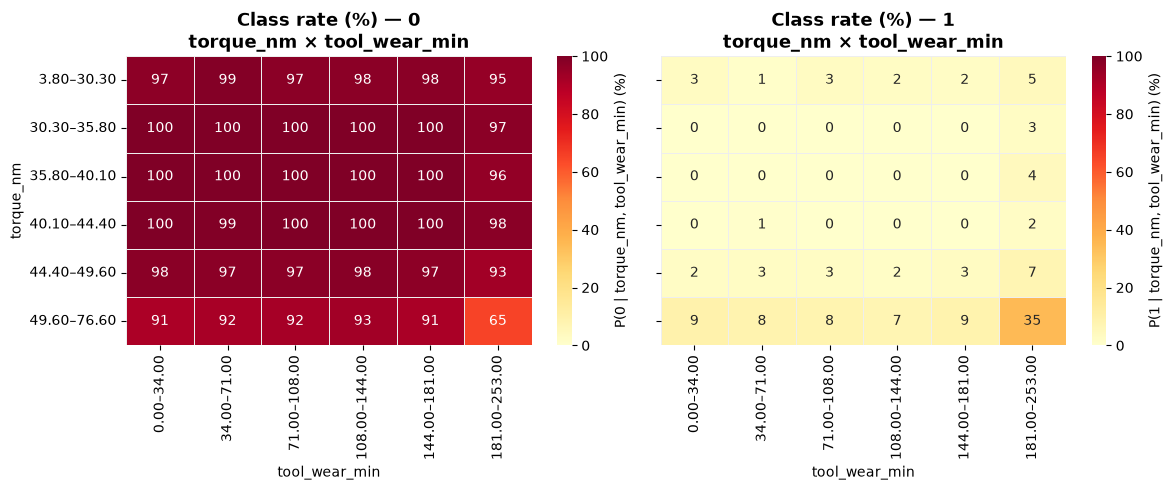

In [86]:
# 
feat1_bins, feat1_labels, feat2_bins, feat2_labels = \
    make_interaction_bins(df,'torque_nm', 'tool_wear_min')

num_num_heatmap(df, target, 'torque_nm', 'tool_wear_min', feat1_bins, feat1_labels, feat2_bins, feat2_labels)

Failure rate rises sharply at high wear combined with extreme torque —
and vanishes where either is moderate. The pair is multiplicative, not
additive: neither variable alone reproduces the corner signal.

In [87]:
# Function for feature interaction num x cat features
def num_cat_heatmap(df_in:pd.DataFrame, target_col:list[str], feat1_num:str, feat2_cat:str, feat_bins:list, feat_labels:list):
    """ Plot interaction heatmap num, cat features, cat target.
    
    """
    df = df_in.copy()
    df[f'{feat1_num}_bucket'] = pd.cut(df[feat1_num], bins=feat_bins,
                            labels=feat_labels, right=False)

    classes = df[target_col[0]].unique().tolist()  # or sorted unique values

    n_classes = len(classes)
    fig, axes = plt.subplots(1, n_classes, figsize=(6 * n_classes, 5), sharey=True)

    if n_classes == 1:
        axes = [axes]  # degenerate case

    for idx, cls in enumerate(classes):
        # 3. Compute P(target == cls | age_bucket, education)
        mask = (df[target_col] == cls).astype(float)

        pivot_cls = (
            df.assign(target_is_cls=mask)
            .groupby([feat2_cat, f'{feat1_num}_bucket'])['target_is_cls']
            .mean()
            .unstack(f'{feat1_num}_bucket')
            .reindex(columns=feat_labels)
            #   .reindex(index=feat_labels)
        )

        ax = axes[idx]
        sns.heatmap(
            pivot_cls * 100,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.4,
            linecolor='#eeeeee',
            cbar_kws={'label': f'P({cls} | {feat1_num}, {feat2_cat}) (%)'},
            ax=ax,
            vmin=0,
            vmax=100,  # same scale across classes
        )
        ax.set_title(
            f'Class rate (%) — {cls}\n{feat1_num} × {feat2_cat}',
            fontsize=13,
            fontweight='bold',
        )
        ax.set_xlabel(f'{feat1_num}')
        if idx == 0:
            ax.set_ylabel(f'{feat2_cat}')
        else:
            ax.set_ylabel('')

    plt.tight_layout()
    plt.show()
    return

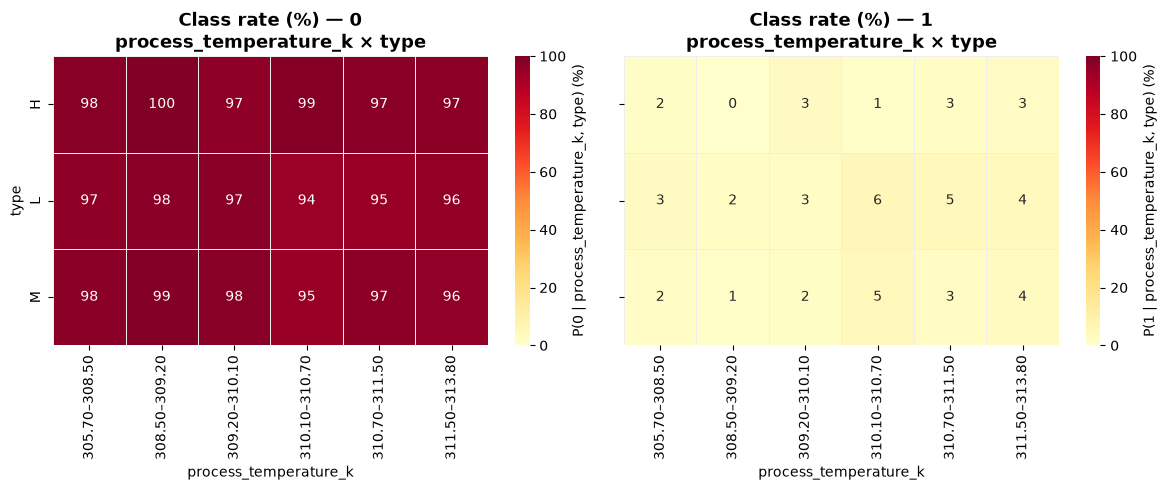

In [88]:
# 
feat1_bins, feat1_labels, _,_ = \
    make_interaction_bins(df,'process_temperature_k', 'tool_wear_min')
num_cat_heatmap(df, target, 'process_temperature_k', 'type', feat1_bins, feat1_labels)

The relationship between process temperature and failure differs across
product series (L/M/H): the gradient is steeper for lower-quality
variants. type is an effect modifier, not only a main effect.

================================================================================
## 8. SUMMARY (new final chapter)
================================================================================

### 8.1 Summary

The AI4I 2020 dataset is a clean, complete, synthetic mechanically-stress
binary failure dataset: 10,000 rows, zero structural or proxy nulls, and a
strictly binary label vocabulary. It is ready for modelling without cleaning,
imputation, or outlier removal. The governing risk is not data quality but
class imbalance and label nuance.

**Data characteristics.** The target has 339 positives out of 10,000 (3.39 %,
≈ 28.5 : 1), making rank metrics (PR-AUC) and stratified sampling the correct
evaluation setup. The five failure-mode columns are outcome columns — derived
labels with two documented inconsistencies (18 mode-positive/target-negative,
9 mode-negative/target-positive rows; 24 multi-mode rows) and must be excluded
from the feature set permanently. Both identifier columns are fully unique
and are lineage fields only.

**Feature signal.** Six features remain: one categorical (`type`, with an
imbalanced 60/30/10 H↔L mix) and five numerics. Spearman correlation shows
near-redundant pairs — air/process temperature and RPM/torque — reducing
independent numeric signal to roughly three features; mutual information
identifies `tool_wear_min`, `torque_nm`, `process_temperature_k`, and `type`
as the strongest candidates. Rotational speed's right tail (skew ≈ 2) marks
a stress regime, not noise.

**Signal shape.** PCA shows one diffuse bulk class with failures at its
edges; Isolation Forest and pairplots agree the positive class occupies a
corner region of (RPM, torque, wear). IQR outliers (4.2 % of RPM readings)
are that corner. Interactions are real: torque × wear is multiplicative
(together, not apart) and process temperature's effect is modified by
product series. Linear models will underperform without manual interaction
terms.

**Modelling implications.**
1. Gradient-boosted trees as primary model family — axis-aligned splits
   capture corner/edge risk; scaling and skew are irrelevant; redundant
   columns are tolerated. A regularized logistic baseline is kept for
   comparison with one-of-each redundant pair dropped.
2. Stratified k-fold CV and PR-AUC (plus recall/precision at an explicit
   threshold) as the evaluation contract; the protected holdout is
   chronological-by-source-row to approximate future data.
3. A fixed leakage guard in Silver: outcome columns are hashed-listed as
   non-features; both IDs are traceability-only; the canonical names/dtypes
   sketched here become the declared Silver contract.
4. No imputation, no outlier deletion, no re-balancing by default —
   documenting the synthetic, complete nature of the source is itself a
   template decision.
5. Optional engineered interaction `torque_nm × tool_wear_min` (and
   temperature × type as a tree-compatible indicator) evaluated by
   cross-validated gain, not ad-hoc inclusion.
